# Metacatalog NED-LVS cross-match

Cross-match the OVRO-LWA **MHz subband** metacatalog against the latest [NED Local Volume Sample](https://ned.ipac.caltech.edu/NED::LVS/) (Cook et al. 2023). Prefer `metacatalog_radio.parquet` from `radio_crossmatch.ipynb` when present so associations use cascaded `match_RA`/`match_DEC` (best bijective VLSSR→NVSS→VLASS position) and survey-appropriate `match_sigma_deg` / `match_source` defaults; otherwise fall back to quality metacatalog `RA`/`DEC` with LWA centroid errors.

Matching gate (degrees): `max(POSITION_SIGMA_SCALE * hypot(σ_meta, σ_ned), DIAM_SCALE * Diam_arcsec)`. `σ_meta` prefers `match_sigma_deg`, else VLSSR/NVSS/VLASS defaults from `match_source`, else LWA `E_RA`/`E_DEC` / `cluster_jitter_rms_deg`. NED-LVS galaxies above `MAX_REDSHIFT` are excluded.

**Primary metric:** fraction of quality-cleared metacatalog rows with a NED-LVS galaxy within that gate.

**SFR–radio plot:** unique matches only (`n_nedlvs == 1`); converts highest-frequency LWA flux (preferring total) to `nu*L_nu` vs NED-LVS SFR.

**Size comparison:** unique matches only; metacatalog `Maj` (FWHM, converted to arcsec) vs NED-LVS projected diameter (`Diam_arcsec`).

**82 MHz flux ECDF:** cumulative fraction of sources vs native `Total_flux_82MHz`.

**Run cells in order.**


In [1]:
from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.analyze import (
    NedlvsMatchConfig,
    build_sfr_radio_luminosity_table,
    filter_by_quality_mask,
    load_nedlvs_catalog,
    match_catalog_to_nedlvs,
    select_metacatalog,
    select_unique_nedlvs_matches,
    summarize_nedlvs_match,
)
from lwa_catalog.constants import (
    NEDLVS_DEFAULT_DIAM_SCALE,
    NEDLVS_DEFAULT_PATH,
    SUBBAND_METACATALOG_REQUIRED_COLUMNS,
)
from lwa_catalog.io import read_table, validate_metacatalog

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")
NEDLVS_PATH = NEDLVS_DEFAULT_PATH
QUALITY_FLAG_MASK = 33267  # HAS_NAN|INVALID_ASTROMETRY|UNPHYSICAL_FLUX|RESID_ABS_FAIL|RESID_PCTL_RMS|RESID_PCTL_MEAN|JITTER_FAIL|LARGE_SINGLE; set None to keep all rows
# Prefer metacatalog_radio.parquet (match_RA/match_DEC/match_source from radio cascade).
USE_RADIO_MATCH_POSITIONS = True

# Metacatalog subset before cross-match:
#   "full" | "blue" | "quality_all_clear" | "query"
# MHz subband catalogs have no Blue band — use "full" (all quality-cleared rows).
METACATALOG_SELECTION = "full"
METACATALOG_QUERY = "Peak_flux_82MHz > 1.0"  # used only when METACATALOG_SELECTION == "query"

# Cross-match gate:
#   max(POSITION_SIGMA_SCALE * hypot(σ_meta, σ_ned), DIAM_SCALE * Diam_arcsec)
POSITION_SIGMA_SCALE = 3.0
DIAM_SCALE = NEDLVS_DEFAULT_DIAM_SCALE  # 0.5; set None to disable galaxy-size floor
MAX_REDSHIFT = 0.1

layout = CatalogLayout(CATALOG_DIR)
RADIO_PATH = layout.metacatalog_radio()
QUALITY_PATH = resolve_metacatalog_path(layout)
USE_RADIO = bool(USE_RADIO_MATCH_POSITIONS and RADIO_PATH.is_file())
METACATALOG_LOAD_PATH = RADIO_PATH if USE_RADIO else QUALITY_PATH
config = NedlvsMatchConfig(
    catalog_path=NEDLVS_PATH,
    target="metacatalog",
    position_sigma_scale=POSITION_SIGMA_SCALE,
    max_redshift=MAX_REDSHIFT,
    diam_scale=DIAM_SCALE,
)

print("CATALOG_DIR =", layout.root.resolve())
print("USE_RADIO_MATCH_POSITIONS =", USE_RADIO_MATCH_POSITIONS)
print("RADIO_PATH =", RADIO_PATH.resolve(), "(exists)" if RADIO_PATH.is_file() else "(missing)")
print("metacatalog load path =", METACATALOG_LOAD_PATH.resolve())
if USE_RADIO_MATCH_POSITIONS and not RADIO_PATH.is_file():
    print("  (radio missing — will fall back to", QUALITY_PATH.resolve(), ")")
print("QUALITY_FLAG_MASK =", QUALITY_FLAG_MASK)
print("NEDLVS_PATH =", Path(NEDLVS_PATH).resolve())
print("METACATALOG_SELECTION =", METACATALOG_SELECTION)
print("POSITION_SIGMA_SCALE =", POSITION_SIGMA_SCALE)
print("DIAM_SCALE =", DIAM_SCALE)
print("MAX_REDSHIFT =", MAX_REDSHIFT)


CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75_subband
USE_RADIO_MATCH_POSITIONS = True
RADIO_PATH = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_radio.parquet (exists)
metacatalog load path = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_radio.parquet
QUALITY_FLAG_MASK = 33267
NEDLVS_PATH = /fast/claw/catalogs/NEDLVS_current.fits
METACATALOG_SELECTION = full
POSITION_SIGMA_SCALE = 3.0
DIAM_SCALE = 0.5
MAX_REDSHIFT = 0.1


## Load metacatalog

Prefer ``metacatalog_radio.parquet`` when `USE_RADIO_MATCH_POSITIONS` is set so NED-LVS matching uses cascaded ``match_RA``/``match_DEC`` (and ``match_source`` / ``match_sigma_deg`` when present). Validates required subband columns, then applies `filter_by_quality_mask`. Otherwise reads ``metacatalog_quality.parquet`` via `read_metacatalog`. Every quality-cleared row is used; there is no Blue-band subset.


In [2]:
if USE_RADIO:
    metacatalog = read_table(RADIO_PATH, as_pandas=True)
    validate_metacatalog(metacatalog, required=SUBBAND_METACATALOG_REQUIRED_COLUMNS)
    if QUALITY_FLAG_MASK is not None:
        metacatalog = filter_by_quality_mask(metacatalog, QUALITY_FLAG_MASK).reset_index(
            drop=True
        )
    print(f"Loaded radio crossmatch: {RADIO_PATH.resolve()}")
elif USE_RADIO_MATCH_POSITIONS:
    print(f"USE_RADIO_MATCH_POSITIONS=True but missing {RADIO_PATH}; falling back to quality metacatalog.")
    metacatalog = read_metacatalog(
        layout,
        prefer_quality=True,
        prefer_spectral=False,
        quality_mask=QUALITY_FLAG_MASK,
    )
else:
    metacatalog = read_metacatalog(
        layout,
        prefer_quality=True,
        prefer_spectral=False,
        quality_mask=QUALITY_FLAG_MASK,
    )

selected_meta = select_metacatalog(
    metacatalog,
    selection=METACATALOG_SELECTION,
    layout=layout,
    query=METACATALOG_QUERY,
)

print(f"metacatalog rows: {len(metacatalog)}")
print(f"selected rows ({METACATALOG_SELECTION}): {len(selected_meta)}")
print(f"quality_flag present: {'quality_flag' in metacatalog.columns}")
print(f"match_RA present: {'match_RA' in selected_meta.columns}")
print(f"match_sigma_deg present: {'match_sigma_deg' in selected_meta.columns}")
if "match_source" in selected_meta.columns:
    print("match_source counts:")
    display(selected_meta["match_source"].astype(str).value_counts())
print(f"spectral columns present: {any(c.startswith('spec_peak_') for c in metacatalog.columns)}")
print(f"Peak_flux_82MHz present: {'Peak_flux_82MHz' in metacatalog.columns}")
print(f"Total_flux_82MHz present: {'Total_flux_82MHz' in metacatalog.columns}")


Loaded radio crossmatch: /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_radio.parquet
metacatalog rows: 128352
selected rows (full): 128352
quality_flag present: True
match_RA present: True
match_sigma_deg present: False
match_source counts:


match_source
LWA      62318
VLSSR    40916
NVSS     15355
VLASS     9763
Name: count, dtype: int64

spectral columns present: False
Peak_flux_82MHz present: True
Total_flux_82MHz present: True


## Load NED-LVS

Loads ~2.1M rows from the FITS table (takes ~15–30 s on lwacalim09).

In [3]:
nedlvs = load_nedlvs_catalog(NEDLVS_PATH)
print(f"NED-LVS rows: {len(nedlvs):,}")
print(f"rows with Diam: {(nedlvs['Diam_arcsec'] > 0).sum():,}")
nedlvs.head()

NED-LVS rows: 2,103,732
rows with Diam: 1,701,193


,objname,RA,DEC,objtype,z,DistMpc,Mstar,SFR_hybrid,SFR_W4,Diam_arcsec
0,b'WISEA J120155.41+623831.1',180.480897,62.641997,b'G',-0.000509,0.0,NaN,NaN,NaN,NaN
1,b'DESI J252.3925+33.8869',252.392549,33.886965,b'G',-0.000409,0.0,NaN,NaN,NaN,NaN
2,b'WISEA J090812.84+514023.6',137.053538,51.673233,b'IrS',-0.000102,0.0,NaN,NaN,NaN,NaN
3,b'DESI J194.2665+32.1772',194.266570,32.177269,b'G',-0.000922,0.0,NaN,NaN,NaN,NaN
4,b'SDSS J120327.61-015758.7',180.865007,-1.966329,b'G',-0.000043,0.0,NaN,NaN,NaN,NaN


## Cross-match against NED-LVS

Associations use ``match_RA``/``match_DEC`` when present, with σ from ``match_sigma_deg`` or ``match_source`` survey defaults (else LWA centroid errors), floored by ``DIAM_SCALE * Diam_arcsec``. ``meta_flags`` records ``match_*`` and ``centroid_sigma_deg`` for diagnostics.


In [4]:
result = match_catalog_to_nedlvs(selected_meta, nedlvs=nedlvs, config=config)
print(summarize_nedlvs_match(result))

LWA target rows:                128352
NED-LVS footprint (Dec box):    998519
Meta matched (>=1 NED-LVS):       6938
Meta with NED-LVS host:         0.054
Meta unique match (n=1):          3542
Meta unique fraction:           0.028
NED-LVS matched (>=1 meta):      21765
NED-LVS recovery:               0.022
NED-LVS over-split (n_meta>1):    2324
Meta multi-NED-LVS (n>1):         3396
Max NED-LVS hits per meta:         166

Warnings:
  - redshift filter z <= 0.1: 923396 NED-LVS rows removed from footprint


## Diagnostics

In [5]:
meta_flags = result.meta_flags
nedlvs_flags = result.nedlvs_flags

print("NED-LVS hits per meta (value_counts):")
display(meta_flags["n_nedlvs"].value_counts().sort_index())

print("\nMeta rows with no NED-LVS host (first 20):")
miss_cols = [
    c
    for c in ["meta_id", "RA", "DEC", "match_RA", "match_DEC", "match_source", "centroid_sigma_deg", "n_nedlvs"]
    if c in meta_flags.columns
]
display(meta_flags.loc[~meta_flags["matched"], miss_cols].head(20))

oversplit_cols = [
    c
    for c in [
        "nedlvs_pos",
        "RA",
        "DEC",
        "objname",
        "DistMpc",
        "n_meta",
        "meta_ids",
        "oversplit",
    ]
    if c in nedlvs_flags.columns
]
print("\nOver-split NED-LVS rows (multiple meta matches, first 20):")
display(nedlvs_flags.loc[nedlvs_flags["oversplit"], oversplit_cols].head(20))


NED-LVS hits per meta (value_counts):


n_nedlvs
0      121414
1        3542
2        1170
3         632
4         408
        ...  
131         1
133         1
137         2
165         1
166         1
Name: count, Length: 64, dtype: int64


Meta rows with no NED-LVS host (first 20):


,meta_id,RA,DEC,match_RA,match_DEC,match_source,centroid_sigma_deg,n_nedlvs
0,1035,68.926554,29.690979,68.926554,29.690979,LWA,0.001389,0
1,445,69.059195,29.705322,69.025448,29.736752,VLSSR,0.000833,0
2,93624,259.840362,-1.186728,259.840362,-1.186728,LWA,0.001389,0
3,6061,6.872708,64.094751,6.872708,64.094751,LWA,0.001389,0
4,93567,6.176412,64.120954,6.176412,64.120954,LWA,0.072279,0
5,131905,5.725083,64.293613,5.725083,64.293613,LWA,0.001389,0
6,399,6.484856,64.166965,6.484856,64.166965,LWA,0.079804,0
7,137016,76.121806,38.381960,76.121806,38.381960,LWA,0.001389,0
9,94089,303.805148,23.602798,303.805148,23.602798,LWA,0.001389,0
10,16672,64.472652,38.203402,64.487736,38.086531,VLSSR,0.000833,0



Over-split NED-LVS rows (multiple meta matches, first 20):


,nedlvs_pos,RA,DEC,objname,DistMpc,n_meta,meta_ids,oversplit
2,2,161.031232,11.534618,b'GALEXASC J104407.59+113202.1',0.000000,2,"[38293, 120838]",True
1508,1508,217.143695,-1.497655,b'DESI J217.1436-01.4976',0.906038,2,"[14998, 119265]",True
1747,1747,135.048118,50.826209,b'WISEA J090011.54+504934.3',1.521468,2,"[15787, 97345]",True
2213,2213,11.888042,-25.288083,b'NGC 0253',3.511539,2,"[136960, 128404]",True
2700,2700,196.453762,-8.020222,b'NGC 4958',6.010138,2,"[59350, 101051]",True
3304,3304,197.879939,36.282001,b'NGC 5014',8.858614,2,"[129473, 29547]",True
3422,3422,245.242333,65.390556,b'NGC 6140',9.336695,2,"[134722, 15847]",True
3524,3524,160.990603,11.703740,b'MESSIER 095',9.745633,2,"[38293, 120838]",True
3601,3601,121.546219,-27.528249,b'ESO 494- G 026',9.980051,2,"[120486, 18904]",True
3786,3786,169.732983,13.092308,b'MESSIER 065',10.558580,2,"[72386, 104201]",True


## NED-LVS recovery vs distance (unique matches only)

For each `DistMpc` threshold, recovery is the fraction of bijective NED-LVS matches (exactly one galaxy per meta row, and one meta row per galaxy) at or closer than that distance.

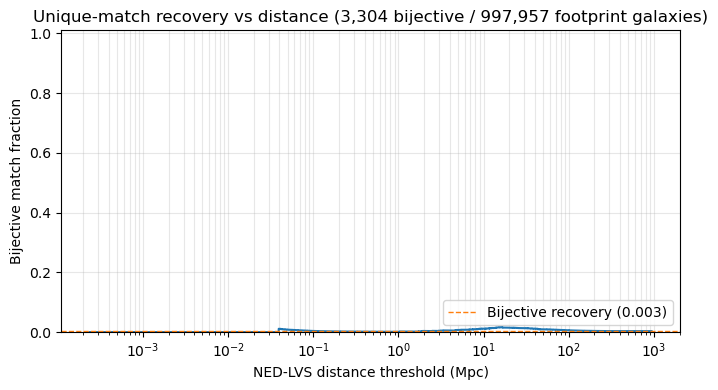

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from lwa_catalog.analyze import select_bijective_nedlvs_flags

bijective_ned = select_bijective_nedlvs_flags(result.meta_flags, result.nedlvs_flags)
bijective_pos = set(bijective_ned["nedlvs_pos"].astype(int).tolist())

footprint_dist = pd.to_numeric(result.nedlvs_footprint["DistMpc"], errors="coerce")
ok = np.isfinite(footprint_dist.to_numpy(dtype=float)) & (footprint_dist > 0)
dist_all = footprint_dist.loc[ok].to_numpy()
matched = np.array(
    [1 if pos in bijective_pos else 0 for pos in footprint_dist.loc[ok].index],
    dtype=int,
)
order = np.argsort(dist_all)
dist_all = dist_all[order]
matched = matched[order]

suffix_matched = np.cumsum(matched)
suffix_total = np.arange(1, len(dist_all) + 1, dtype=float)
recovery = suffix_matched / suffix_total
overall = float(suffix_matched[-1] / suffix_total[-1]) if len(dist_all) else float("nan")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dist_all, recovery, drawstyle="steps-post")
ax.axhline(
    overall,
    color="C1",
    ls="--",
    lw=1,
    label=f"Bijective recovery ({overall:.3f})",
)
ax.set_xscale("log")
ax.set_xlabel("NED-LVS distance threshold (Mpc)")
ax.set_ylabel("Bijective match fraction")
ax.set_ylim(0, 1.01)
ax.set_title(
    f"Unique-match recovery vs distance ({int(suffix_matched[-1]):,} bijective / "
    f"{len(dist_all):,} footprint galaxies)"
)
ax.legend(loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## SFR–radio luminosity relation (unique matches only)

Uses only meta rows with exactly one NED-LVS association (`n_nedlvs == 1`). For each pair with NED-LVS SFR and redshift, the highest-frequency positive LWA flux (preferring `Total_flux_{band}`, falling back to peak) is converted to `nu*L_nu` and plotted versus SFR.


In [7]:
unique_meta = select_unique_nedlvs_matches(result.meta_flags)
print(
    f"unique meta matches: {len(unique_meta):,} / {len(result.meta_flags):,} matched rows"
)

sfr_radio = build_sfr_radio_luminosity_table(
    selected_meta,
    result.nedlvs_footprint,
    result.meta_flags,
    unique_only=True,
)
print(f"unique pairs with SFR + radio luminosity: {len(sfr_radio)}")
display(sfr_radio.head())

unique meta matches: 3,542 / 128,352 matched rows
unique pairs with SFR + radio luminosity: 3155


,meta_id,objname,z,SFR,SFR_column,radio_band,radio_freq_hz,Flux_jy,L_nu_erg_s_hz,nuL_nu_erg_s
0,999,b'WISEA J091929.10-114107.5',0.052740,0.473795,SFR_W4,NVSS,1.400000e+09,0.017600,1.242967e+30,1.740154e+39
1,34,b'WISEA J092127.83+454702.2',0.031218,0.538590,SFR_hybrid,VLASS,3.000000e+09,0.534210,1.281518e+31,3.844555e+40
2,23143,b'WISEA J012633.29-012312.7',0.017800,0.047704,SFR_hybrid,82MHz,8.200000e+07,2.232220,1.706718e+31,1.399509e+39
3,47249,b'WISEA J192258.94+434916.8',0.093811,1.746377,SFR_hybrid,VLASS,3.000000e+09,0.005831,1.378617e+30,4.135851e+39
4,20103,b'WISEA J215452.24+380735.6',0.059127,1.019754,SFR_W4,VLASS,3.000000e+09,0.007446,6.669404e+29,2.000821e+39


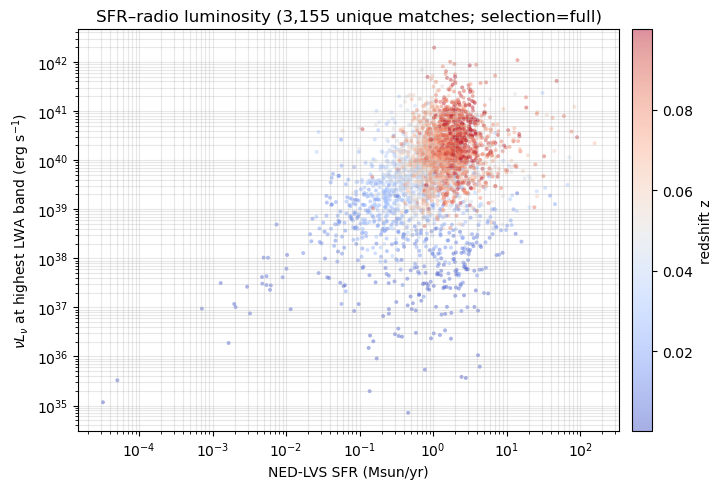

In [8]:
if sfr_radio.empty:
    print("No SFR–radio pairs to plot.")
else:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    sc = ax.scatter(
        sfr_radio["SFR"],
        sfr_radio["nuL_nu_erg_s"],
        c=sfr_radio["z"],
        cmap="coolwarm",
        s=8,
        alpha=0.45,
        edgecolors="none",
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("redshift z")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("NED-LVS SFR (Msun/yr)")
    ax.set_ylabel(r"$\nu L_\nu$ at highest LWA band (erg s$^{-1}$)")
    ax.set_title(
        f"SFR–radio luminosity ({len(sfr_radio):,} unique matches; "
        f"selection={METACATALOG_SELECTION})"
    )
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Metacatalog Maj vs NED-LVS projected size (unique matches only)

Compares PyBDSF major-axis FWHM (`Maj`, degrees → arcsec) with the NED-LVS galaxy projected diameter (`Diam_arcsec`). Only bijective meta↔NED pairs are shown.

unique pairs with Maj + NED-LVS Diam: 3,307


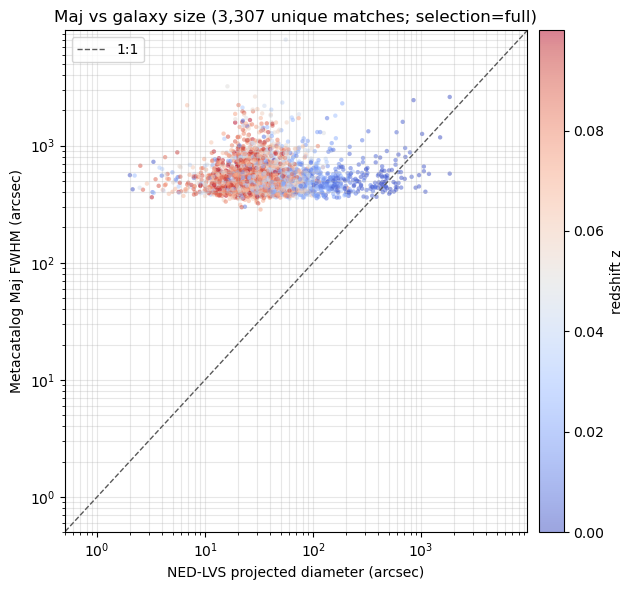

In [9]:
unique_flags = select_unique_nedlvs_matches(result.meta_flags)
meta_by_id = selected_meta.set_index("meta_id", drop=False)

size_records: list[dict] = []
for _, flag in unique_flags.iterrows():
    if not bool(flag.get("matched", False)):
        continue
    positions = flag.get("nedlvs_positions", [])
    if len(positions) != 1:
        continue

    meta_id = flag["meta_id"]
    if meta_id not in meta_by_id.index:
        continue
    meta_row = meta_by_id.loc[meta_id]
    if isinstance(meta_row, pd.DataFrame):
        meta_row = meta_row.iloc[0]

    maj_deg = pd.to_numeric(meta_row.get("Maj"), errors="coerce")
    ned_row = result.nedlvs_footprint.iloc[int(positions[0])]
    diam_arcsec = pd.to_numeric(ned_row.get("Diam_arcsec"), errors="coerce")
    if not (
        np.isfinite(maj_deg)
        and float(maj_deg) > 0.0
        and np.isfinite(diam_arcsec)
        and float(diam_arcsec) > 0.0
    ):
        continue

    size_records.append(
        {
            "meta_id": meta_id,
            "Maj_arcsec": float(maj_deg) * 3600.0,
            "Diam_arcsec": float(diam_arcsec),
            "z": pd.to_numeric(ned_row.get("z"), errors="coerce"),
        }
    )

size_pairs = pd.DataFrame.from_records(size_records)
print(f"unique pairs with Maj + NED-LVS Diam: {len(size_pairs):,}")

if size_pairs.empty:
    print("No size pairs to plot.")
else:
    lim = np.nanmax(
        [size_pairs["Maj_arcsec"].max(), size_pairs["Diam_arcsec"].max()]
    )
    lim = max(float(lim) * 1.2, 1.0)

    fig, ax = plt.subplots(figsize=(6.5, 6))
    sc = ax.scatter(
        size_pairs["Diam_arcsec"],
        size_pairs["Maj_arcsec"],
        c=size_pairs["z"],
        cmap="coolwarm",
        s=10,
        alpha=0.5,
        edgecolors="none",
    )
    ax.plot([0.0, lim], [0.0, lim], color="0.35", ls="--", lw=1, label="1:1")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.5, lim)
    ax.set_ylim(0.5, lim)
    ax.set_xlabel("NED-LVS projected diameter (arcsec)")
    ax.set_ylabel("Metacatalog Maj FWHM (arcsec)")
    ax.set_title(
        f"Maj vs galaxy size ({len(size_pairs):,} unique matches; "
        f"selection={METACATALOG_SELECTION})"
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("redshift z")
    ax.legend(loc="upper left")
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Cumulative 82 MHz total flux

Plots the empirical cumulative distribution of positive `Total_flux_82MHz` on the selected MHz subband metacatalog.

Total_flux_82MHz: 90,300 positive finite sources (full @ metacatalog_coaddR-0.75_subband)


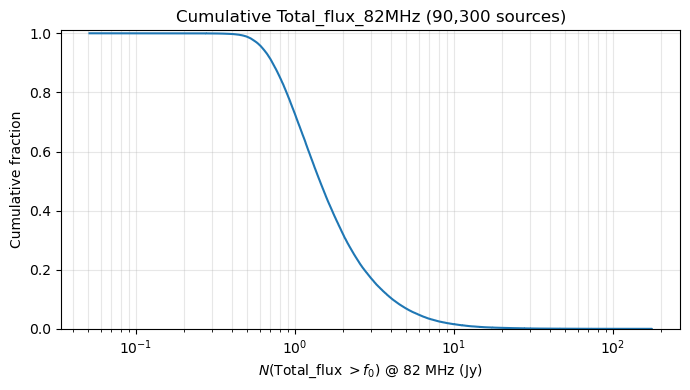

In [10]:
FLUX_82_COL = "Total_flux_82MHz"
flux_source_label = f"{METACATALOG_SELECTION} @ {CATALOG_DIR.name}"

if FLUX_82_COL not in selected_meta.columns:
    print(f"{FLUX_82_COL} not available for the selected metacatalog.")
else:
    flux = pd.to_numeric(selected_meta[FLUX_82_COL], errors="coerce").to_numpy(dtype=float)
    flux = np.sort(flux[np.isfinite(flux) & (flux > 0)])
    n_flux = len(flux)
    print(f"{FLUX_82_COL}: {n_flux:,} positive finite sources ({flux_source_label})")

    if n_flux == 0:
        print("No positive 82 MHz flux values to plot.")
    else:
        cum_frac = (np.arange(1, n_flux + 1, dtype=float) / n_flux)[::-1]

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(flux, cum_frac, drawstyle="steps-post", color="C0")
        ax.set_xscale("log")
        ax.set_xlabel(r"$N$(Total_flux $> f_0$) @ 82 MHz (Jy)")
        ax.set_ylabel("Cumulative fraction")
        ax.set_ylim(0, 1.01)
        ax.set_title(f"Cumulative Total_flux_82MHz ({n_flux:,} sources)")
        ax.grid(True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()